In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px 
import seaborn as sns 

In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\archive (4)\\Spotify Streaming Performance Dataset.csv")
df = data.copy()
df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [3]:
df.columns = df.columns.str.replace(" ",'_').str.strip()

In [4]:
df.columns

Index(['Artist_Name', 'Sex', 'Country_of_Origin', 'Primary_Language',
       'Primary_Genre', '_Artist_Type', 'Debut_Year',
       'Total_Streams_(in_millions)', 'Lead_Streams_(in_millions)',
       'Feature_Streams_(in_millions)', 'Solo_Streams_(in_millions)',
       '%_of_Solo_Streams', 'Collaborative_Streams_(in_millions)',
       '%_of_Collaborative_Streams'],
      dtype='object')

In [5]:
df.shape

(500, 14)

In [6]:
df.describe()

,Debut_Year,Total_Streams_(in_millions),Lead_Streams_(in_millions),Feature_Streams_(in_millions),Solo_Streams_(in_millions),%_of_Solo_Streams,Collaborative_Streams_(in_millions),%_of_Collaborative_Streams
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2005.346000,16817.610200,12141.734000,4681.289000,8324.397600,50.613084,8493.212600,49.386916
std,13.312578,14845.197632,11844.675186,5952.827762,9589.010168,33.762147,9612.491536,33.762147
min,1939.000000,6972.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.750000,8768.175000,6489.750000,696.500000,2519.775000,20.117951,2015.650000,16.860219
50%,2009.000000,11923.250000,8716.350000,3005.600000,6472.950000,47.062829,6592.250000,52.937171
75%,2014.000000,18020.050000,13456.900000,6093.350000,10115.550000,83.139781,11019.575000,79.882049
max,2023.000000,137492.100000,126177.300000,43710.500000,113421.500000,100.000000,84168.200000,100.000000


In [7]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols_summary = {}

for col in cat_cols:
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percent': percents.round(2)})
    cat_cols_summary[col] = summary

cat_cols_summary


{'Artist_Name':                Count  Percent
 Artist_Name                  
 Drake              1      0.2
 Taylor Swift       1      0.2
 Bad Bunny          1      0.2
 The Weeknd         1      0.2
 Justin Bieber      1      0.2
 ...              ...      ...
 The Cure           1      0.2
 The Marías         1      0.2
 Limp Bizkit        1      0.2
 Korn               1      0.2
 Omar Courtz        1      0.2
 
 [500 rows x 2 columns],
 'Sex':         Count  Percent
 Sex                   
 Male      390     78.0
 Female     88     17.6
 Mixed      22      4.4,
 'Country_of_Origin':                      Count  Percent
 Country_of_Origin                  
 United States          265     53.0
 United Kingdom          55     11.0
 Mexico                  27      5.4
 Canada                  18      3.6
 Colombia                16      3.2
 Brazil                  15      3.0
 India                   13      2.6
 South Korea             11      2.2
 Argentina                9      1.8

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.drop_duplicates()

,Artist_Name,Sex,Country_of_Origin,Primary_Language,Primary_Genre,_Artist_Type,Debut_Year,Total_Streams_(in_millions),Lead_Streams_(in_millions),Feature_Streams_(in_millions),Solo_Streams_(in_millions),%_of_Solo_Streams,Collaborative_Streams_(in_millions),%_of_Collaborative_Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,The Cure,Male,United Kingdom,English,Rock,Group,1979,7034.1,7035.0,3.3,6940.1,98.663653,94.0,1.336347
496,The Marías,Mixed,United States,English,Pop,Group,2017,7029.1,5774.4,1261.4,5705.9,81.175399,1323.2,18.824601
497,Limp Bizkit,Male,United States,English,Nu Metal,Group,1997,7018.9,7018.4,5.4,6806.0,96.966761,212.9,3.033239
498,Korn,Male,United States,English,Metal,Group,1994,6976.4,4188.4,2798.5,6414.9,91.951436,561.5,8.048564


In [10]:
num_col = df.select_dtypes(include = 'number').columns

Q1 = df[num_col].quantile(0.25)
Q3 = df[num_col].quantile(0.75)
IQR = Q3-Q1

outliers = (df[num_col] < Q1 - 1.5*IQR) | (df[num_col] > Q3 + 1.5*IQR)
outliers.shape

(500, 8)

In [11]:
country_language = df.groupby('Country_of_Origin')['Primary_Language'].value_counts().reset_index().head(10)
country_language

,Country_of_Origin,Primary_Language,count
0,Argentina,Spanish,9
1,Australia,English,7
2,Austria,German,1
3,Barbados,English,1
4,Belgium,English,1
5,Brazil,Portuguese,15
6,Canada,English,17
7,Canada,French,1
8,Chile,Spanish,1
9,Colombia,Spanish,15


In [12]:
genre_counts = df['Primary_Genre'].value_counts().reset_index()
genre_counts.columns = ['Primary_Genre', 'Count']


fig = px.bar(
    genre_counts,
    x='Primary_Genre',
    y='Count',
    color='Count',  
    color_continuous_scale='magma',
    title='Distribution of Primary_Genre'
)

fig.update_layout(
    xaxis_title='Primary_Genre',
    yaxis_title='Count',
    xaxis_tickangle=45
)

fig.show()


In [13]:
import plotly.express as px

# Compute top 15 countries
top_countries = df['Country_of_Origin'].value_counts().reset_index().head(15)
top_countries.columns = ['Country_of_Origin', 'Count']

# Plot with Plotly Express
fig = px.bar(
    top_countries,
    x='Count',
    y='Country_of_Origin',
    color='Count',
    color_continuous_scale='tealrose', 
    title='Top 15 Countries (Artists)'
)


fig.update_layout(
    xaxis_title='Count',
    yaxis_title='Country of Origin',
    yaxis=dict(categoryorder='total ascending')  
)

fig.show()


<Axes: >

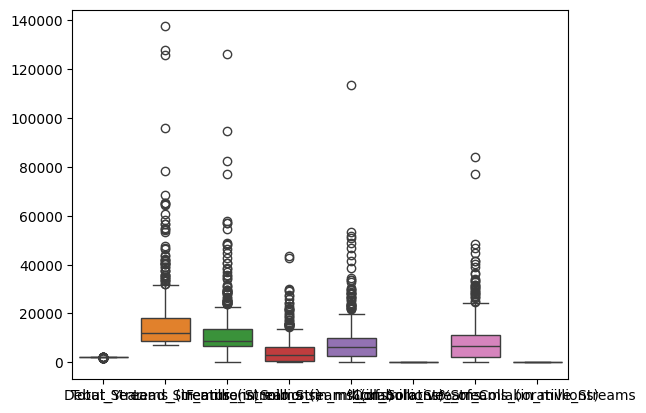

In [14]:
import seaborn as sns
sns.boxplot(df)

,Artist_Name,Sex,Country_of_Origin,Primary_Language,Primary_Genre,_Artist_Type,Debut_Year,Total_Streams_(in_millions),Lead_Streams_(in_millions),Feature_Streams_(in_millions),Solo_Streams_(in_millions),%_of_Solo_Streams,Collaborative_Streams_(in_millions),%_of_Collaborative_Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970
